# Projet Bank Marketing — Notebook expliqué

Ce notebook prépare le dataset Bank Marketing, applique l'encodage et la standardisation, puis entraîne deux modèles de classification : la régression logistique et l'arbre de décision. Chaque étape est accompagnée d'une explication courte pour faciliter la compréhension du code.

## 1. Importation des bibliothèques principales
Cette cellule importe les bibliothèques nécessaires pour manipuler les données, créer des graphiques et entraîner une régression logistique. `pandas` sert à gérer les tableaux de données, `matplotlib` et `seaborn` servent à visualiser les résultats, et les fonctions de `sklearn` servent à entraîner et évaluer le modèle.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score



## 2. Chargement du dataset
Cette cellule charge le fichier `bank-full.csv`. Le paramètre `sep=";"` est important, car ce fichier utilise le point-virgule comme séparateur entre les colonnes. `head(1)` permet d'afficher la première ligne pour vérifier que le dataset est bien chargé.

In [2]:
data=pd.read_csv("bank-full.csv",sep=";")
print(data.head(1))
#(data.columns)

   age         job  marital education default  balance housing loan  contact  \
0   58  management  married  tertiary      no     2143     yes   no  unknown   

   day month  duration  campaign  pdays  previous poutcome   y  
0    5   may       261         1     -1         0  unknown  no  


## 3. Taille du dataset
Cette cellule affiche la forme du dataset avec le nombre de lignes et le nombre de colonnes. Cela permet de savoir rapidement le volume de données disponible.

In [3]:
data.shape

(45211, 17)

## 4. Structure des données
Cette cellule affiche les informations générales du dataset : noms des colonnes, types de données et présence éventuelle de valeurs manquantes. Elle aide à comprendre la structure avant le nettoyage.

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## 5. Identification des variables numériques et catégorielles
Cette cellule sépare automatiquement les colonnes numériques et les colonnes catégorielles. Cette distinction est importante, car les traitements ne sont pas les mêmes pour les nombres et pour les textes.

In [5]:
# Identifier les variables numériques
variables_numeriques = data.select_dtypes(include=["int64", "float64"]).columns

# Identifier les variables catégorielles
variables_categorielles = data.select_dtypes(include=["object"]).columns

# Afficher les résultats
print("Variables numériques :")
print(list(variables_numeriques))

print("\nVariables catégorielles :")
print(list(variables_categorielles))

Variables numériques :
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Variables catégorielles :
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


## 6. Vérification des valeurs manquantes classiques
Cette cellule compte les valeurs manquantes reconnues par pandas, comme `NaN`. Elle permet de vérifier si certaines colonnes contiennent des cellules vides.

In [6]:
valeurs_manquantes = data.isnull().sum()
print(valeurs_manquantes)

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


## 7. Vérification des valeurs inconnues
Dans ce dataset, certaines valeurs manquantes sont écrites sous forme de texte avec `unknown`. Cette cellule compte le nombre de `unknown` dans chaque colonne afin de les traiter ensuite.

In [7]:
valeurs_inconnues = (data == "unknown").sum()

print("Valeurs inconnues par colonne :")
print(valeurs_inconnues)


Valeurs inconnues par colonne :
age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64


## 8. Nouvelle vérification des informations du dataset
Cette cellule réaffiche les informations du dataset pour confirmer les types de données et l'état général des colonnes après les premières vérifications.

In [8]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


## 9. Vérification des doublons
Cette cellule compte les lignes dupliquées. Les doublons peuvent fausser l'analyse ou l'entraînement du modèle, car ils donnent trop d'importance à certaines observations.

In [9]:
doublons = data.duplicated().sum()

print("Nombre de doublons :", doublons)

Nombre de doublons : 0


## Analyse de la variable cible
Cette section étudie la colonne `y`, qui indique si un client a souscrit (`yes`) ou non (`no`) au dépôt à terme.

## 10. Nombre de valeurs de la variable cible
Cette cellule affiche combien de clients ont répondu `yes` et combien ont répondu `no`. Elle permet de voir directement si les classes sont équilibrées ou non.

In [10]:
print(data["y"].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


## 11. Pourcentage de chaque classe
Cette cellule affiche la proportion de `yes` et de `no` en pourcentage. C'est important pour comprendre le déséquilibre des classes avant l'entraînement du modèle.

In [11]:
print(data["y"].value_counts(normalize=True) * 100)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


## 12. Analyse univariée de toutes les colonnes
Cette cellule analyse chaque colonne séparément. Pour chaque variable, elle affiche le nombre de valeurs, le pourcentage de chaque valeur et un graphique adapté au type de variable. Les variables numériques sont affichées avec un histogramme, et les variables catégorielles avec un diagramme en barres.


Analyse de la colonne : age
     Nombre  Pourcentage (%)
age                         
32     2085         4.611710
31     1996         4.414855
33     1972         4.361770
34     1930         4.268873
35     1894         4.189246
..      ...              ...
93        2         0.004424
90        2         0.004424
95        2         0.004424
88        2         0.004424
94        1         0.002212

[77 rows x 2 columns]


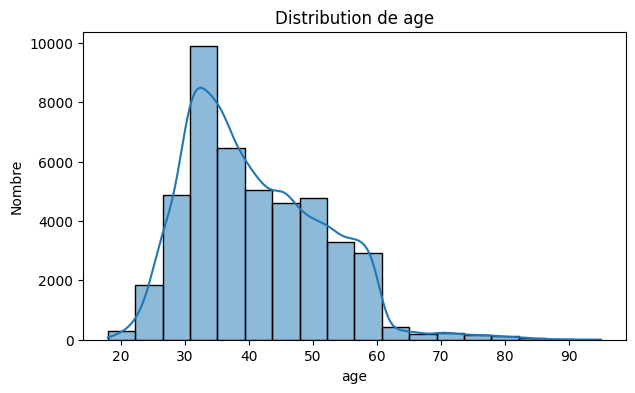


Analyse de la colonne : job
               Nombre  Pourcentage (%)
job                                   
blue-collar      9732        21.525735
management       9458        20.919688
technician       7597        16.803433
admin.           5171        11.437482
services         4154         9.188029
retired          2264         5.007631
self-employed    1579         3.492513
entrepreneur     1487         3.289023
unemployed       1303         2.882042
housemaid        1240         2.742695
student           938         2.074716
unknown           288         0.637013


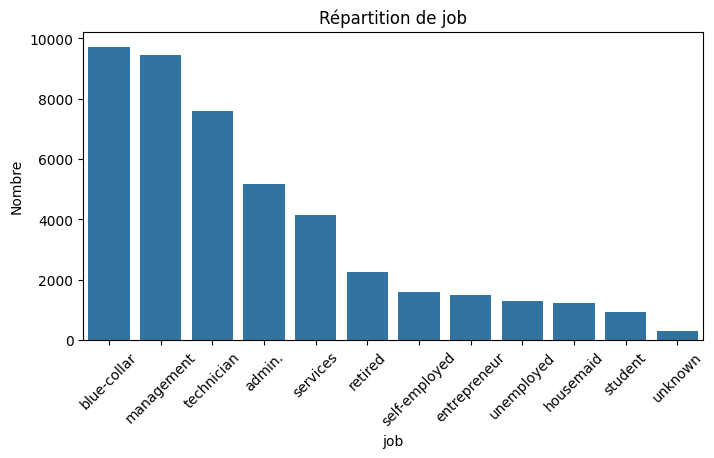


Analyse de la colonne : marital
          Nombre  Pourcentage (%)
marital                          
married    27214        60.193316
single     12790        28.289576
divorced    5207        11.517109


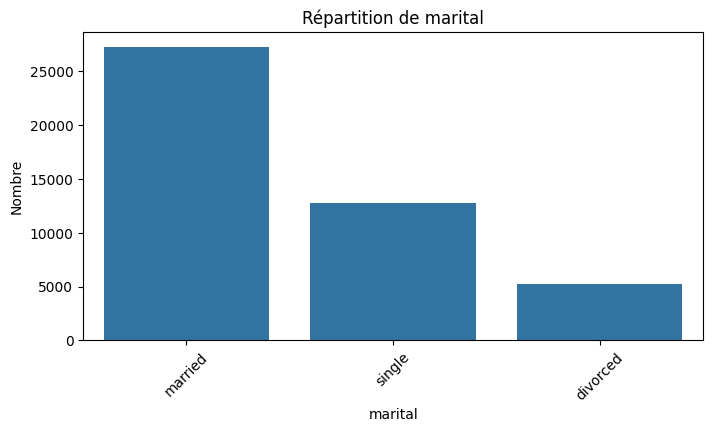


Analyse de la colonne : education
           Nombre  Pourcentage (%)
education                         
secondary   23202        51.319369
tertiary    13301        29.419831
primary      6851        15.153392
unknown      1857         4.107407


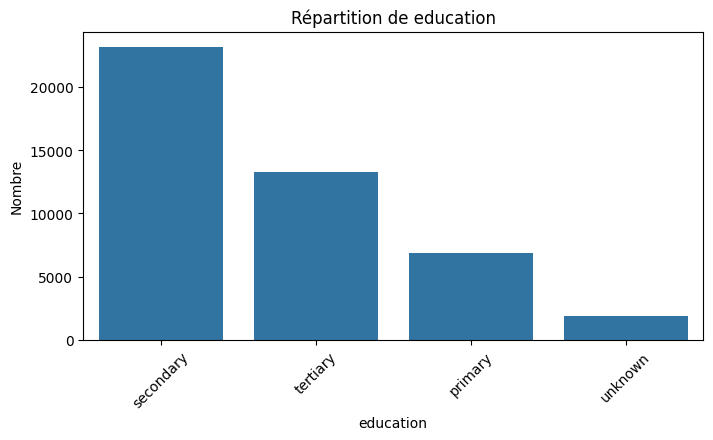


Analyse de la colonne : default
         Nombre  Pourcentage (%)
default                         
no        44396        98.197341
yes         815         1.802659


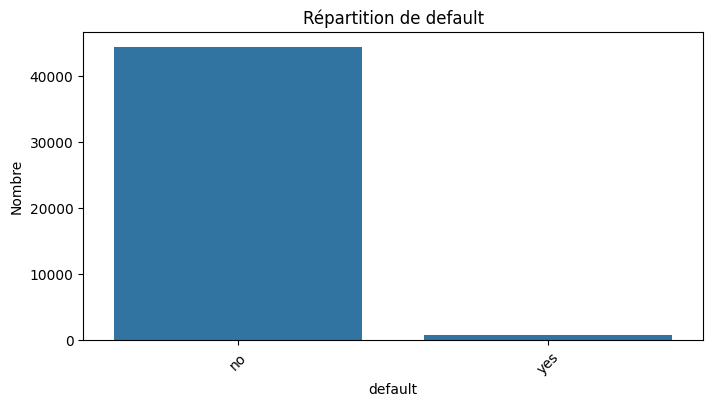


Analyse de la colonne : balance
         Nombre  Pourcentage (%)
balance                         
 0         3514         7.772445
 1          195         0.431311
 2          156         0.345049
 4          139         0.307447
 3          134         0.296388
...         ...              ...
-381          1         0.002212
 4617         1         0.002212
 20584        1         0.002212
 4358         1         0.002212
 16353        1         0.002212

[7168 rows x 2 columns]


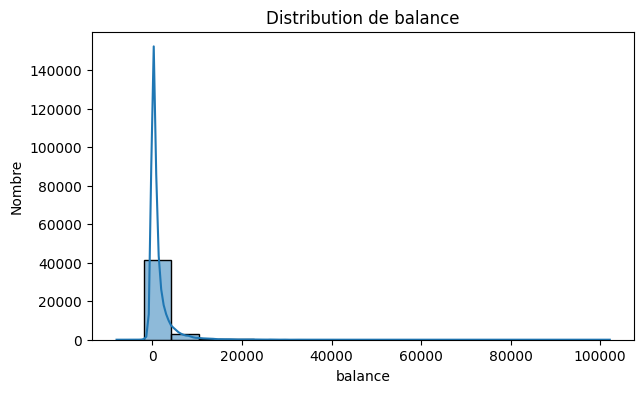


Analyse de la colonne : housing
         Nombre  Pourcentage (%)
housing                         
yes       25130        55.583818
no        20081        44.416182


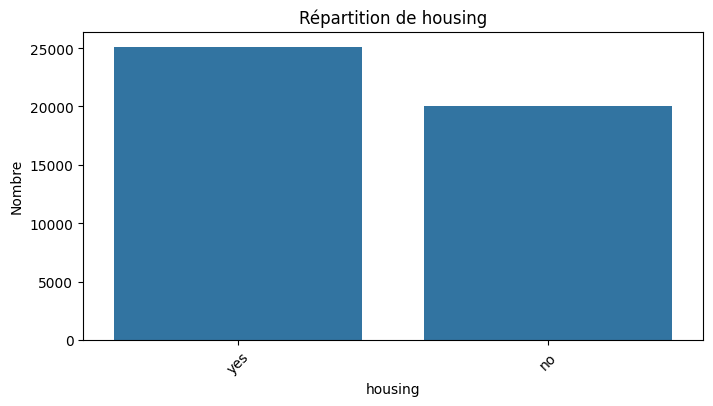


Analyse de la colonne : loan
      Nombre  Pourcentage (%)
loan                         
no     37967        83.977351
yes     7244        16.022649


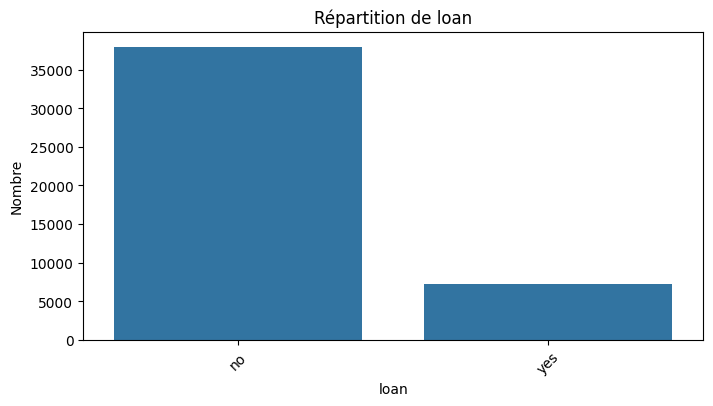


Analyse de la colonne : contact
           Nombre  Pourcentage (%)
contact                           
cellular    29285        64.774059
unknown     13020        28.798301
telephone    2906         6.427639


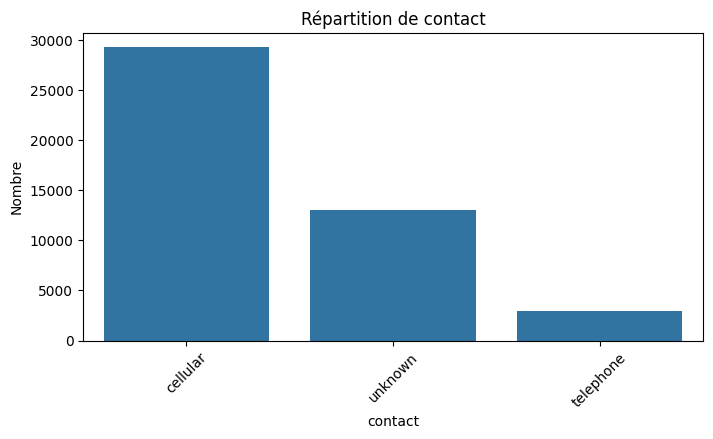


Analyse de la colonne : day
     Nombre  Pourcentage (%)
day                         
20     2752         6.087014
18     2308         5.104952
21     2026         4.481210
17     1939         4.288779
6      1932         4.273296
5      1910         4.224636
14     1848         4.087501
8      1842         4.074230
28     1830         4.047688
7      1817         4.018933
19     1757         3.886222
29     1745         3.859680
15     1703         3.766782
12     1603         3.545597
13     1585         3.505784
30     1566         3.463759
9      1561         3.452700
11     1479         3.271328
4      1445         3.196125
16     1415         3.129769
2      1293         2.859923
27     1121         2.479485
3      1079         2.386587
26     1035         2.289266
23      939         2.076928
22      905         2.001725
25      840         1.857955
31      643         1.422220
10      524         1.159010
24      447         0.988697
1       322         0.712216


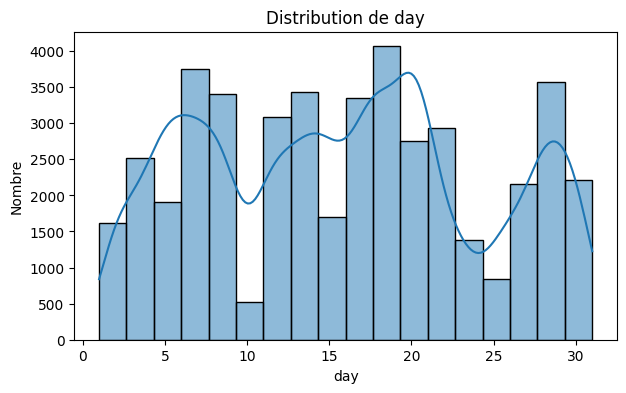


Analyse de la colonne : month
       Nombre  Pourcentage (%)
month                         
may     13766        30.448342
jul      6895        15.250713
aug      6247        13.817434
jun      5341        11.813497
nov      3970         8.781049
apr      2932         6.485147
feb      2649         5.859194
jan      1403         3.103227
oct       738         1.632346
sep       579         1.280662
mar       477         1.055053
dec       214         0.473336


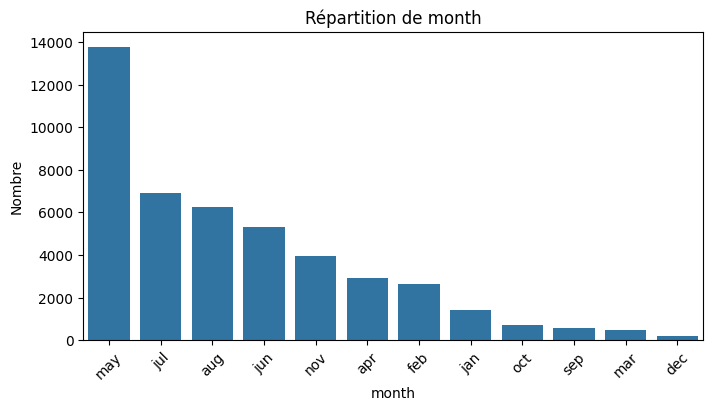


Analyse de la colonne : duration
          Nombre  Pourcentage (%)
duration                         
124          188         0.415828
90           184         0.406981
89           177         0.391498
104          175         0.387074
122          175         0.387074
...          ...              ...
1833           1         0.002212
1545           1         0.002212
1352           1         0.002212
1342           1         0.002212
1556           1         0.002212

[1573 rows x 2 columns]


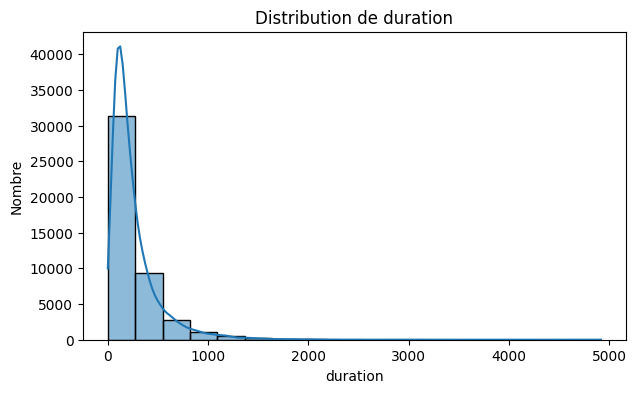


Analyse de la colonne : campaign
          Nombre  Pourcentage (%)
campaign                         
1          17544        38.804716
2          12505        27.659198
3           5521        12.211630
4           3522         7.790140
5           1764         3.901705
6           1291         2.855500
7            735         1.625711
8            540         1.194400
9            327         0.723275
10           266         0.588352
11           201         0.444582
12           155         0.342837
13           133         0.294176
14            93         0.205702
15            84         0.185795
16            79         0.174736
17            69         0.152618
18            51         0.112804
19            44         0.097321
20            43         0.095110
21            35         0.077415
22            23         0.050873
25            22         0.048661
23            22         0.048661
24            20         0.044237
29            16         0.035390
28            

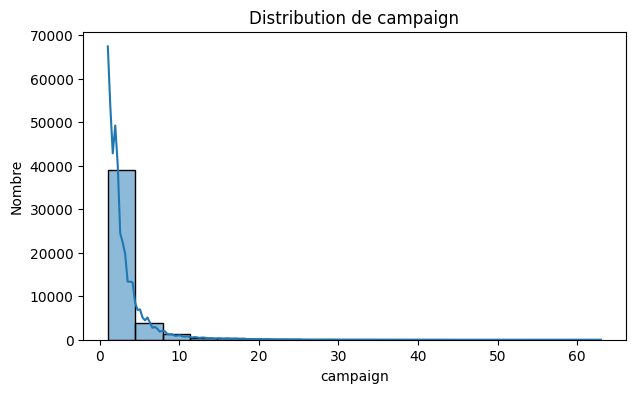


Analyse de la colonne : pdays
       Nombre  Pourcentage (%)
pdays                         
-1      36954        81.736745
 182      167         0.369379
 92       147         0.325142
 91       126         0.278693
 183      126         0.278693
...       ...              ...
 449        1         0.002212
 452        1         0.002212
 648        1         0.002212
 595        1         0.002212
 530        1         0.002212

[559 rows x 2 columns]


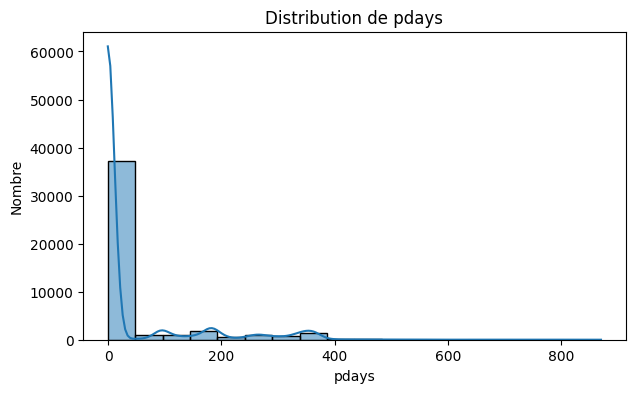


Analyse de la colonne : previous
          Nombre  Pourcentage (%)
previous                         
0          36954        81.736745
1           2772         6.131251
2           2106         4.658158
3           1142         2.525934
4            714         1.579262
5            459         1.015240
6            277         0.612683
7            205         0.453429
8            129         0.285329
9             92         0.203490
10            67         0.148194
11            65         0.143770
12            44         0.097321
13            38         0.084050
15            20         0.044237
14            19         0.042025
17            15         0.033178
16            13         0.028754
19            11         0.024330
20             8         0.017695
23             8         0.017695
18             6         0.013271
22             6         0.013271
24             5         0.011059
27             5         0.011059
21             4         0.008847
29            

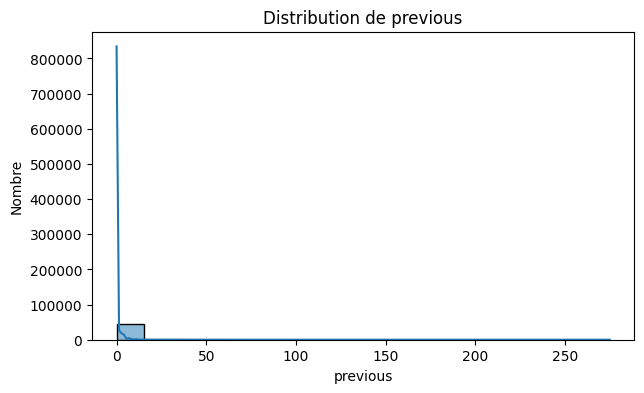


Analyse de la colonne : poutcome
          Nombre  Pourcentage (%)
poutcome                         
unknown    36959        81.747805
failure     4901        10.840282
other       1840         4.069806
success     1511         3.342107


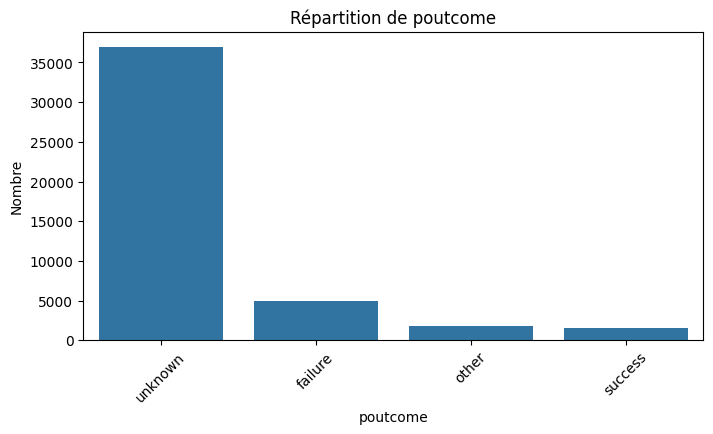


Analyse de la colonne : y
     Nombre  Pourcentage (%)
y                           
no    39922         88.30152
yes    5289         11.69848


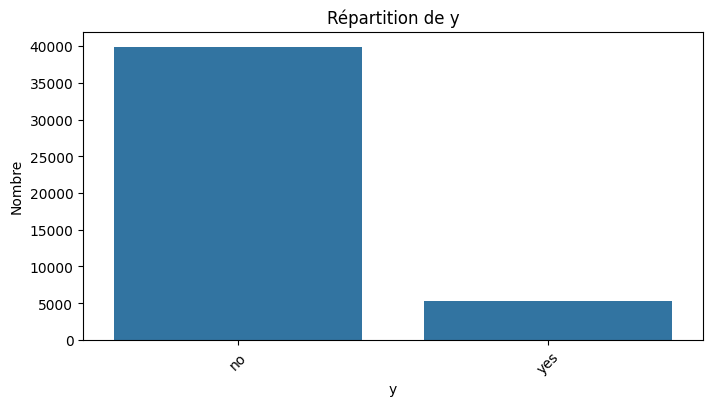

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

for col in data.columns:
    
    print("\n" + "="*50)
    print(f"Analyse de la colonne : {col}")
    print("="*50)
    
    count_values = data[col].value_counts()
    percentage_values = data[col].value_counts(normalize=True) * 100
    
    resume = pd.DataFrame({
        "Nombre": count_values,
        "Pourcentage (%)": percentage_values
    })
    
    print(resume)
    
    if data[col].dtype in ["int64", "float64"]:
        plt.figure(figsize=(7, 4))
        sns.histplot(data=data, x=col, kde=True, bins=18)
        plt.title(f"Distribution de {col}")
        plt.xlabel(col)
        plt.ylabel("Nombre")
        plt.show()
    else:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=data, x=col, order=data[col].value_counts().index)
        plt.title(f"Répartition de {col}")
        plt.xlabel(col)
        plt.ylabel("Nombre")
        plt.xticks(rotation=45)
        plt.show()

## 13. Analyse des variables catégorielles par rapport à la cible
Cette cellule utilise des tableaux croisés pour comparer chaque variable catégorielle avec la variable cible `y`. L'objectif est de voir, pour chaque catégorie, le pourcentage de clients qui ont répondu `yes` ou `no`.

In [13]:
import pandas as pd

# Identifier les variables catégorielles
variables_categorielles = data.select_dtypes(include=["object"]).columns.tolist()

# Retirer la variable cible y
variables_categorielles.remove("y")

# Tableau de pourcentage pour chaque variable catégorielle par rapport à y
for col in variables_categorielles:
    print("\n" + "="*60)
    print(f"Tableau de pourcentage : {col} par rapport à y")
    print("="*60)
    
    tableau_pourcentage = pd.crosstab(
        data[col],
        data["y"],
        normalize="index"
    ) * 100
    
    print(tableau_pourcentage)


Tableau de pourcentage : job par rapport à y
y                     no        yes
job                                
admin.         87.797331  12.202669
blue-collar    92.725031   7.274969
entrepreneur   91.728312   8.271688
housemaid      91.209677   8.790323
management     86.244449  13.755551
retired        77.208481  22.791519
self-employed  88.157061  11.842939
services       91.116996   8.883004
student        71.321962  28.678038
technician     88.943004  11.056996
unemployed     84.497314  15.502686
unknown        88.194444  11.805556

Tableau de pourcentage : marital par rapport à y
y                no        yes
marital                       
divorced  88.054542  11.945458
married   89.876534  10.123466
single    85.050821  14.949179

Tableau de pourcentage : education par rapport à y
y                 no        yes
education                      
primary    91.373522   8.626478
secondary  89.440565  10.559435
tertiary   84.993610  15.006390
unknown    86.429725  13.570275



## Nettoyage des données
Cette section traite les valeurs inconnues afin de rendre les données plus propres avant l'encodage et l'entraînement des modèles.

## 14. Nettoyage des valeurs `unknown`
Cette cellule remplace certaines valeurs `unknown` par des valeurs plus explicites. Par exemple, `job` devient `no job`, `education` devient `no education`, et `poutcome` devient `no previous campaign`. Pour `contact`, les valeurs inconnues sont remplacées par la valeur la plus fréquente hors `unknown`.

In [14]:
data["job"] = data["job"].replace("unknown", "no job")

data["education"] = data["education"].replace("unknown", "no education")

mode_contact = data.loc[data["contact"] != "unknown", "contact"].mode()[0]

data["contact"] = data["contact"].replace("unknown", mode_contact)

data["poutcome"] = data["poutcome"].replace("unknown", "no previous campaign")

## 15. Vérification après nettoyage
Cette cellule vérifie s'il reste encore des valeurs `unknown` après les remplacements. Si le résultat est vide, cela signifie que les valeurs inconnues ont bien été traitées.

In [15]:
valeurs_inconnues = (data == "unknown").sum()

print("Valeurs inconnues après remplacement :")
print(valeurs_inconnues[valeurs_inconnues > 0])

Valeurs inconnues après remplacement :
Series([], dtype: int64)


## Encodage et standardisation
Cette section transforme la cible, sépare les données, encode les variables catégorielles et standardise les variables numériques.

## 16. Copie du dataset et encodage de la cible
Cette cellule crée une copie du dataset pour garder les données originales intactes. Ensuite, elle transforme la variable cible `y` en numérique : `no` devient 0 et `yes` devient 1.

In [16]:
# Copier le dataset pour ne pas modifier l'original
data_model = data.copy()

# Transformer la variable cible y en numérique
data_model["y_num"] = data_model["y"].map({"no": 0, "yes": 1})

## 17. Séparation entre variables explicatives et cible
Cette cellule sépare les données en deux parties : `X`, qui contient les variables utilisées pour prédire, et `y`, qui contient la réponse à prédire. La colonne `y_num` devient la cible du modèle.

In [17]:
# X = variables explicatives
X = data_model.drop(columns=["y", "y_num"])

# y = variable cible
y = data_model["y_num"]

## 18. Séparation train/test
Cette cellule divise les données en jeu d'entraînement et jeu de test. Le modèle apprend sur le train, puis il est évalué sur le test. Le paramètre `stratify=y` garde la même proportion de `yes` et `no` dans les deux ensembles.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 19. Identification des colonnes à encoder
Cette cellule identifie les variables catégorielles et numériques dans le jeu d'entraînement. Les variables catégorielles devront être transformées en valeurs numériques avant l'entraînement.

In [19]:
# Variables catégorielles
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

# Variables numériques
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variables catégorielles :", cat_cols)
print("Variables numériques :", num_cols)

Variables catégorielles : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Variables numériques : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## 20. K-Fold Target Encoding
Cette cellule transforme les variables catégorielles en valeurs numériques avec le K-Fold Target Encoding. Chaque catégorie est remplacée par le taux moyen de `yes`, tout en limitant le risque de fuite de données grâce aux folds. Le test est encodé uniquement avec les informations apprises sur le train.

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold

# Copies des datasets
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Moyenne globale de la cible
global_mean = y_train.mean()

# K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for col in cat_cols:
    
    # Créer une colonne vide dans le train
    X_train_encoded[col] = np.nan
    
    # Encodage K-Fold sur le train
    for train_index, valid_index in kf.split(X_train, y_train):
        
        X_train_fold = X_train.iloc[train_index]
        y_train_fold = y_train.iloc[train_index]
        X_valid_fold = X_train.iloc[valid_index]
        
        # Calcul du taux moyen de y pour chaque catégorie
        target_mean = y_train_fold.groupby(X_train_fold[col]).mean()
        
        # Application sur la partie validation
        X_train_encoded.iloc[
            valid_index,
            X_train_encoded.columns.get_loc(col)
        ] = X_valid_fold[col].map(target_mean)
    
    # Remplacer les valeurs manquantes par la moyenne globale
    X_train_encoded[col] = X_train_encoded[col].fillna(global_mean)
    
    # Encodage du test avec les moyennes calculées sur tout le train
    target_mean_test = y_train.groupby(X_train[col]).mean()
    X_test_encoded[col] = X_test[col].map(target_mean_test)
    X_test_encoded[col] = X_test_encoded[col].fillna(global_mean)

## 21. Vérification après encodage
Cette cellule affiche les premières lignes et les types des colonnes après encodage. L'objectif est de vérifier que les anciennes variables catégorielles sont devenues numériques.

In [21]:
print(X_train_encoded.head())
print(X_train_encoded.dtypes)

       age       job   marital  education   default  balance   housing  \
24001   36  0.109113  0.123027   0.106485  0.118026      861  0.168977   
43409   24  0.301459  0.150722   0.107750  0.118020     4126  0.166978   
20669   44  0.110720  0.148243   0.106244  0.117947      244  0.077480   
18810   48  0.161290  0.099529   0.107140  0.118030        0  0.166365   
23130   38  0.110720  0.100968   0.106244  0.117947      257  0.166797   

           loan   contact  day     month  duration  campaign  pdays  previous  \
24001  0.126628  0.140625   29  0.112525       140         2     -1         0   
43409  0.126498  0.114994    5  0.192328       907         4    185         7   
20669  0.126103  0.115671   12  0.103121      1735         4     -1         0   
18810  0.125701  0.134667   31  0.093253        35        11     -1         0   
23130  0.126103  0.115671   26  0.103121        57        10     -1         0   

       poutcome  
24001  0.092314  
43409  0.121474  
20669  0.09256

## 22. Standardisation des variables
Cette cellule applique la standardisation avec `StandardScaler`. La standardisation met les variables sur une échelle comparable, avec une moyenne proche de 0 et un écart-type proche de 1. Le scaler apprend uniquement sur le train, puis applique la même transformation au test.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Apprendre la standardisation sur le train
X_train_scaled_array = scaler.fit_transform(X_train_encoded)

# Appliquer la même transformation sur le test
X_test_scaled_array = scaler.transform(X_test_encoded)

## 23. Reconstruction des DataFrames standardisés
Après la standardisation, les données sont converties en tableaux NumPy. Cette cellule les retransforme en DataFrames pandas afin de conserver les noms des colonnes et les index.

In [23]:
X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=X_train_encoded.columns,
    index=X_train_encoded.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=X_test_encoded.columns,
    index=X_test_encoded.index
)

## 24. Vérification des données standardisées
Cette cellule affiche un aperçu des données standardisées ainsi que les dimensions du train et du test. Elle permet de vérifier que la préparation des données s'est bien déroulée.

In [24]:
print(X_train_scaled.head())
print(X_train_scaled.shape)
print(X_test_scaled.shape)

            age       job   marital  education   default   balance   housing  \
24001 -0.460434 -0.177249  0.275736  -0.466020  0.132268 -0.164410  1.160072   
43409 -1.589641  4.157927  1.538628  -0.409826  0.131472  0.899627  1.115475   
20669  0.292371 -0.141035  1.425612  -0.476714  0.122388 -0.365486 -0.881233   
18810  0.668773  0.998740 -0.795762  -0.436906  0.132790 -0.445003  1.101816   
23130 -0.272233 -0.141035 -0.730128  -0.476714  0.122388 -0.361249  1.111445   

           loan   contact       day     month  duration  campaign     pdays  \
24001  0.450770  3.981918  1.582124 -0.053728 -0.457311 -0.246104 -0.410910   
43409  0.444700 -0.333844 -1.298384  0.910344  2.502493  0.398202  1.446096   
20669  0.426216 -0.219774 -0.458236 -0.167332  5.697691  0.398202 -0.410910   
18810  0.407418  2.978775  1.822166 -0.286550 -0.862499  2.653271 -0.410910   
23130  0.426216 -0.219774  1.222060 -0.167332 -0.777602  2.331118 -0.410910   

       previous  poutcome  
24001 -0.241509 

## 25. Heatmap de corrélation
Cette cellule crée une matrice de corrélation entre les variables numériques encodées et la cible. La heatmap permet de visualiser rapidement les relations positives ou négatives entre les variables.

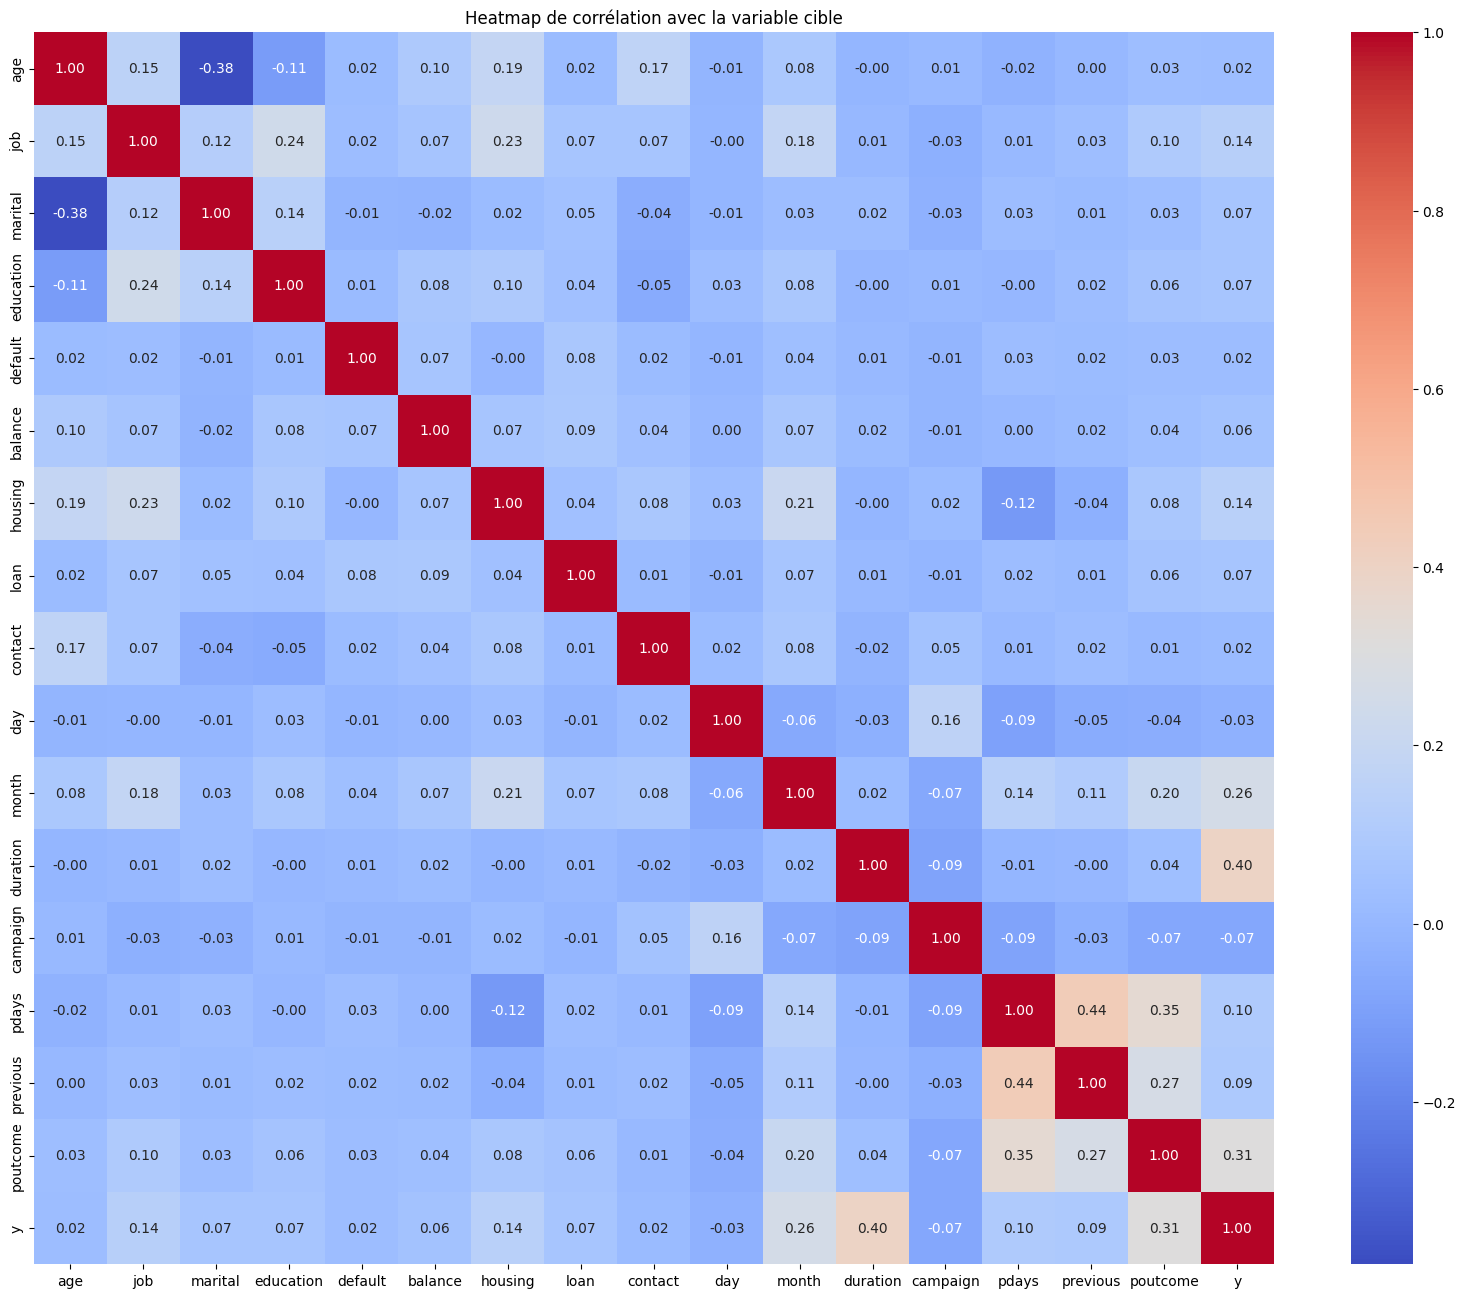

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Créer un dataset train avec X encodé + y
train_corr = X_train_encoded.copy()
train_corr["y"] = y_train

# Matrice de corrélation
corr_matrix = train_corr.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Heatmap de corrélation avec la variable cible")
plt.show()

## 26. Création du modèle de régression logistique
Cette cellule crée le modèle de régression logistique. `class_weight="balanced"` aide le modèle à prendre en compte le déséquilibre entre les classes `no` et `yes`. `max_iter=3000` donne suffisamment d'itérations au modèle pour apprendre correctement.

In [26]:
model_logistic = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=52
)

## 27. Entraînement de la régression logistique
Cette cellule entraîne le modèle avec les données standardisées du train. Pendant cette étape, le modèle apprend les poids des variables et le biais.

In [27]:
model_logistic.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,52
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


## 28. Prédictions et probabilités de la régression logistique
Cette cellule produit les prédictions finales avec `predict` et les probabilités de la classe `yes` avec `predict_proba`. Les prédictions donnent 0 ou 1, tandis que les probabilités indiquent le niveau de confiance du modèle pour la classe `yes`.

In [28]:
y_pred = model_logistic.predict(X_test_scaled)
print(y_pred)

y_proba = model_logistic.predict_proba(X_test_scaled)[:, 1]
print(y_proba)


[0 0 0 ... 0 0 0]
[0.09658339 0.08744186 0.09627176 ... 0.27167473 0.40846663 0.09383841]


## Note sur la séparation des données
Les variables explicatives `X` sont préparées séparément de la cible `y`. La cible a déjà été transformée en 0 et 1, tandis que les variables catégorielles de `X` sont encodées avec le K-Fold Target Encoding.

## 29. Évaluation de la régression logistique
Cette cellule calcule l'accuracy, le ROC-AUC et le rapport de classification. Ces métriques permettent d'évaluer la performance globale du modèle, ainsi que ses résultats pour chaque classe.

In [29]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy :", accuracy)
print("ROC-AUC :", roc_auc)

print("\nClassification Report :")
print(classification_report(y_test, y_pred))

Accuracy : 0.8424195510339489
ROC-AUC : 0.9029617205227666

Classification Report :
              precision    recall  f1-score   support

           0       0.97      0.85      0.90      7985
           1       0.41      0.79      0.54      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.82      0.72      9043
weighted avg       0.90      0.84      0.86      9043



## 30. Interprétation des coefficients de la régression logistique
Cette cellule affiche le biais du modèle et le poids associé à chaque variable. Un poids positif augmente la probabilité de prédire `yes`, tandis qu'un poids négatif diminue cette probabilité.

In [30]:
import pandas as pd

# Biais du modèle
bias = model_logistic.intercept_[0]

print("Biais du modèle :", bias)

# Poids des variables
poids = model_logistic.coef_[0]

# Créer un tableau clair avec les noms des colonnes
coef_df = pd.DataFrame({
    "Variable": X_train_scaled.columns,
    "Poids": poids
})

# Trier les poids du plus positif au plus négatif
coef_df = coef_df.sort_values(by="Poids", ascending=False)

print(coef_df)

Biais du modèle : -0.9429619046964456
     Variable     Poids
11   duration  1.462948
10      month  0.526487
15   poutcome  0.476473
6     housing  0.445025
1         job  0.208488
7        loan  0.201856
2     marital  0.163431
3   education  0.144941
14   previous  0.101931
13      pdays  0.099200
5     balance  0.075883
8     contact  0.029053
4     default  0.025478
0         age -0.028158
9         day -0.049736
12   campaign -0.280132


## Arbre de décision
Cette section ajoute un deuxième modèle de classification. L'arbre de décision permet d'obtenir un modèle basé sur des règles de séparation, plus facile à interpréter.

## 31. Imports pour l'arbre de décision
Cette cellule importe le modèle `DecisionTreeClassifier` et les métriques nécessaires pour entraîner et évaluer un arbre de décision.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

## 32. Création du modèle arbre de décision
Cette cellule crée un arbre de décision avec une profondeur maximale de 5. `class_weight="balanced"` permet de tenir compte du déséquilibre entre les classes `no` et `yes`.

In [32]:
model_tree = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

## 33. Entraînement de l'arbre de décision
Cette cellule entraîne l'arbre de décision sur les données encodées. Pour ce type de modèle, la standardisation n'est pas obligatoire, car l'arbre fonctionne avec des règles de séparation.

In [33]:
model_tree.fit(X_train_encoded, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


## 34. Prédictions finales de l'arbre de décision
Cette cellule utilise l'arbre entraîné pour prédire la classe finale sur le jeu de test. Le résultat est 0 pour `no` et 1 pour `yes`.

In [34]:
# Prédiction finale : 0 = no, 1 = yes
y_pred_tree = model_tree.predict(X_test_encoded)

print("Prédictions finales :")
print(y_pred_tree)

Prédictions finales :
[0 0 0 ... 0 0 0]


## 35. Probabilités des deux classes
Cette cellule récupère les probabilités prédites par l'arbre de décision pour les deux classes. La colonne 0 correspond à `no`, et la colonne 1 correspond à `yes`.

In [35]:
# Probabilités des deux classes
y_proba_tree_all = model_tree.predict_proba(X_test_encoded)

# Vérifier l'ordre des classes
print("Ordre des classes :", model_tree.classes_)

# Colonne 0 = probabilité de no
proba_no = y_proba_tree_all[:, 0]

# Colonne 1 = probabilité de yes
proba_yes = y_proba_tree_all[:, 1]

print("Probabilités de no :")
print(proba_no)

print("Probabilités de yes :")
print(proba_yes)

Ordre des classes : [0 1]
Probabilités de no :
[0.68407974 0.90566071 0.90566071 ... 0.68407974 0.95450367 0.91176527]
Probabilités de yes :
[0.31592026 0.09433929 0.09433929 ... 0.31592026 0.04549633 0.08823473]


## 36. Tableau des résultats de l'arbre de décision
Cette cellule crée un tableau clair contenant la vraie classe, la prédiction finale, la probabilité de `no` et la probabilité de `yes` pour chaque client du jeu de test.

In [36]:
resultats_tree = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": y_pred_tree,
    "proba_no": proba_no,
    "proba_yes": proba_yes
})

print("Aperçu des résultats :")
print(resultats_tree.head(20))

Aperçu des résultats :
    y_reel  y_pred  proba_no  proba_yes
0        0       0  0.684080   0.315920
1        0       0  0.905661   0.094339
2        0       0  0.905661   0.094339
3        0       0  0.954504   0.045496
4        0       0  0.911765   0.088235
5        0       1  0.462003   0.537997
6        0       0  0.954504   0.045496
7        1       1  0.080195   0.919805
8        0       0  0.954504   0.045496
9        0       0  0.954504   0.045496
10       0       0  0.954504   0.045496
11       0       0  0.684080   0.315920
12       0       0  0.697787   0.302213
13       0       0  0.954504   0.045496
14       0       0  0.684080   0.315920
15       0       0  0.954504   0.045496
16       0       1  0.271533   0.728467
17       0       0  0.954504   0.045496
18       1       1  0.170412   0.829588
19       0       0  0.954504   0.045496


## 37. Évaluation de l'arbre de décision
Cette cellule calcule les métriques de performance de l'arbre de décision : accuracy, ROC-AUC et rapport de classification. Cela permet de comparer ce modèle avec la régression logistique.

In [37]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)

# ROC-AUC utilise la probabilité de la classe positive : yes = 1
roc_auc_tree = roc_auc_score(y_test, proba_yes)

print("Accuracy :", accuracy_tree)
print("ROC-AUC :", roc_auc_tree)

print("\nClassification Report :")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=["no", "yes"]
))

Accuracy : 0.7963065354417782
ROC-AUC : 0.8848454036573775

Classification Report :
              precision    recall  f1-score   support

          no       0.97      0.79      0.87      7985
         yes       0.35      0.83      0.49      1058

    accuracy                           0.80      9043
   macro avg       0.66      0.81      0.68      9043
weighted avg       0.90      0.80      0.83      9043



## 38. Matrice de confusion de l'arbre de décision
Cette cellule affiche la matrice de confusion. Elle permet de voir combien de clients `no` et `yes` ont été bien ou mal classés par le modèle.

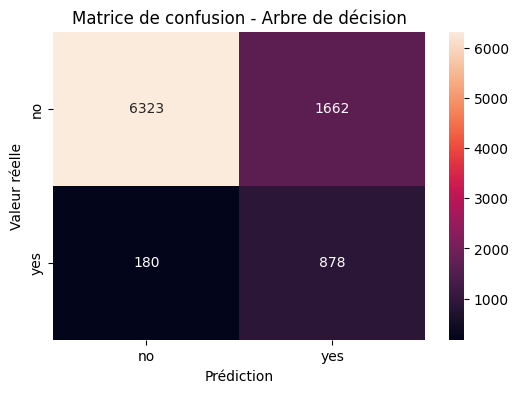

In [38]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    xticklabels=["no", "yes"],
    yticklabels=["no", "yes"]
)

plt.title("Matrice de confusion - Arbre de décision")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.show()

## 39. Importance des variables avec l'arbre de décision
Cette cellule affiche l'importance de chaque variable selon l'arbre de décision. Plus une variable est importante, plus elle a été utile pour séparer les classes pendant l'entraînement.

In [39]:
importance_tree = pd.DataFrame({
    "Variable": X_train_encoded.columns,
    "Importance": model_tree.feature_importances_
})

importance_tree = importance_tree.sort_values(
    by="Importance",
    ascending=False
)

print("Importance des variables :")
print(importance_tree)

Importance des variables :
     Variable  Importance
11   duration    0.543352
10      month    0.203629
15   poutcome    0.121447
6     housing    0.092928
13      pdays    0.023477
9         day    0.008036
0         age    0.003206
3   education    0.001779
7        loan    0.001587
5     balance    0.000320
1         job    0.000239
2     marital    0.000000
4     default    0.000000
8     contact    0.000000
12   campaign    0.000000
14   previous    0.000000


## 40. Visualisation de l'importance des variables
Cette cellule affiche graphiquement l'importance des variables. Cela permet d'identifier rapidement les colonnes qui influencent le plus l'arbre de décision.

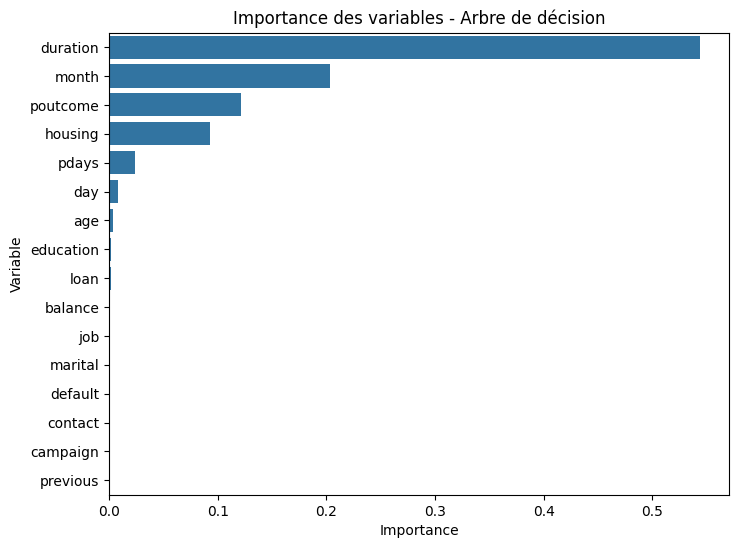

In [40]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=importance_tree,
    x="Importance",
    y="Variable"
)

plt.title("Importance des variables - Arbre de décision")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()